In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve


In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [49]:
data = pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\900D_heart_disease_dataset.csv")

In [50]:
data.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [51]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [52]:
X_train = data.drop("target", axis=1) 
y_train = data.iloc[:, -1] 


In [53]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [54]:
test = pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\100D_test_dataset.csv")

In [55]:
X_test=test.drop("target", axis=1) 
y_test=test["target"]

In [56]:
y_pred = model.predict(X_test)

In [57]:
accuracy = accuracy_score(y_test, y_pred)

In [58]:
accuracy

0.86

In [59]:
print(f"Test Data Predictions: {y_pred}")
print(f"Actual Test Data:      {y_test.values}")
print(f"Model Accuracy on Test Data: {accuracy:.2f}")

Test Data Predictions: [0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 1 1 0 1 1 0 1 0 1 1 0 1 1 0 0 0 1 0 0 1 0 0
 1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 0 0 1 1 1 1 1 1 0 1 1 1 1 0 1 0 0 0 0 0
 0 1 1 0 1 1 1 1 0 1 1 1 1 0 0 0 1 1 0 0 1 1 1 0 0 1]
Actual Test Data:      [0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1 0 0 0 0 1 0 0 1 0 1
 1 1 0 1 1 0 0 1 1 1 0 1 0 1 0 1 0 0 0 1 1 0 0 1 1 0 1 1 0 1 0 1 0 0 0 0 0
 0 1 1 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 0 0 1 1 1 0 0 1]
Model Accuracy on Test Data: 0.86


In [60]:
results = {
    "Dataset": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "ROC-AUC": []
}

In [61]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

In [62]:
results["Accuracy"].append(acc)
results["Precision"].append(prec)
results["Recall"].append(rec)
results["ROC-AUC"].append(auc)

In [63]:
results_df = pd.DataFrame(results, columns=["TrainSize","Accuracy","Precision","Recall","AUC"])

In [64]:
print(results_df)

  TrainSize  Accuracy  Precision   Recall  AUC
0       NaN      0.86        0.8  0.93617  NaN


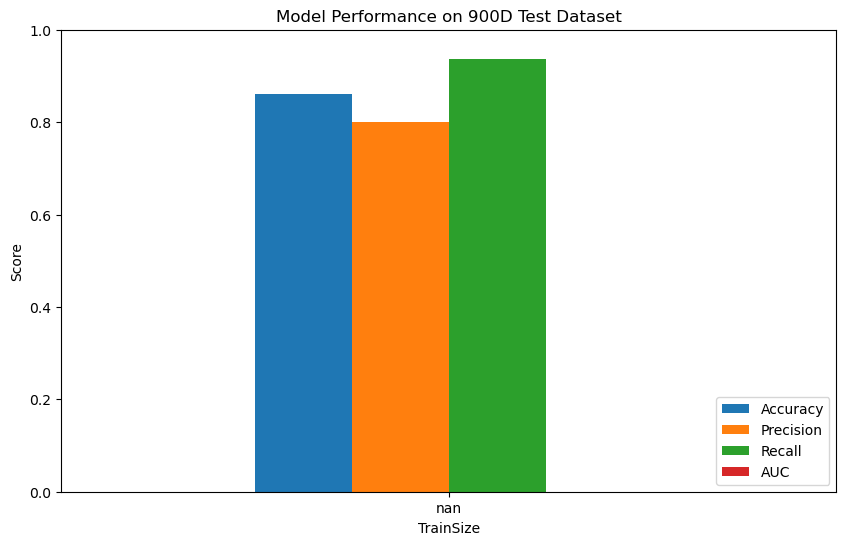

In [65]:
results_df.set_index("TrainSize").plot(kind="bar", figsize=(10,6))
plt.title("Model Performance on 900D Test Dataset")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

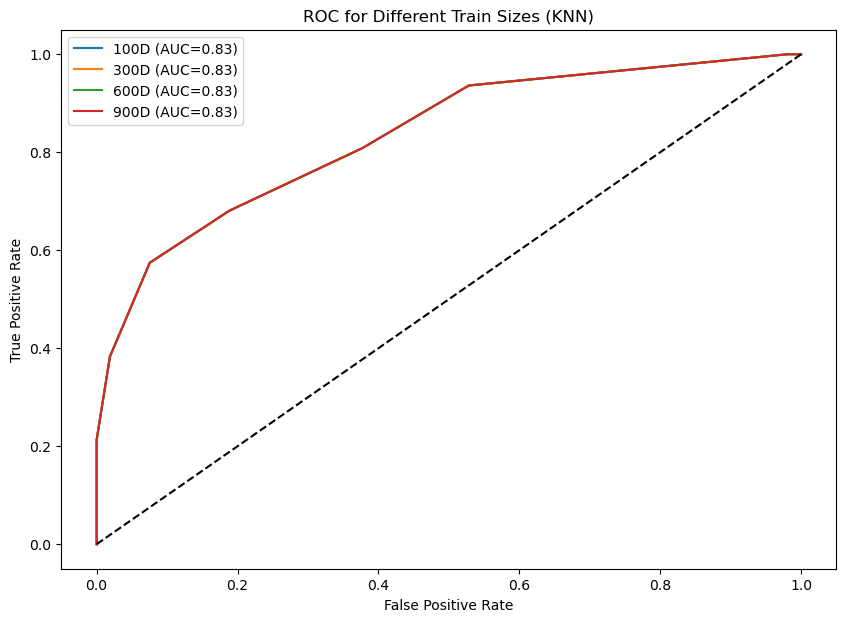

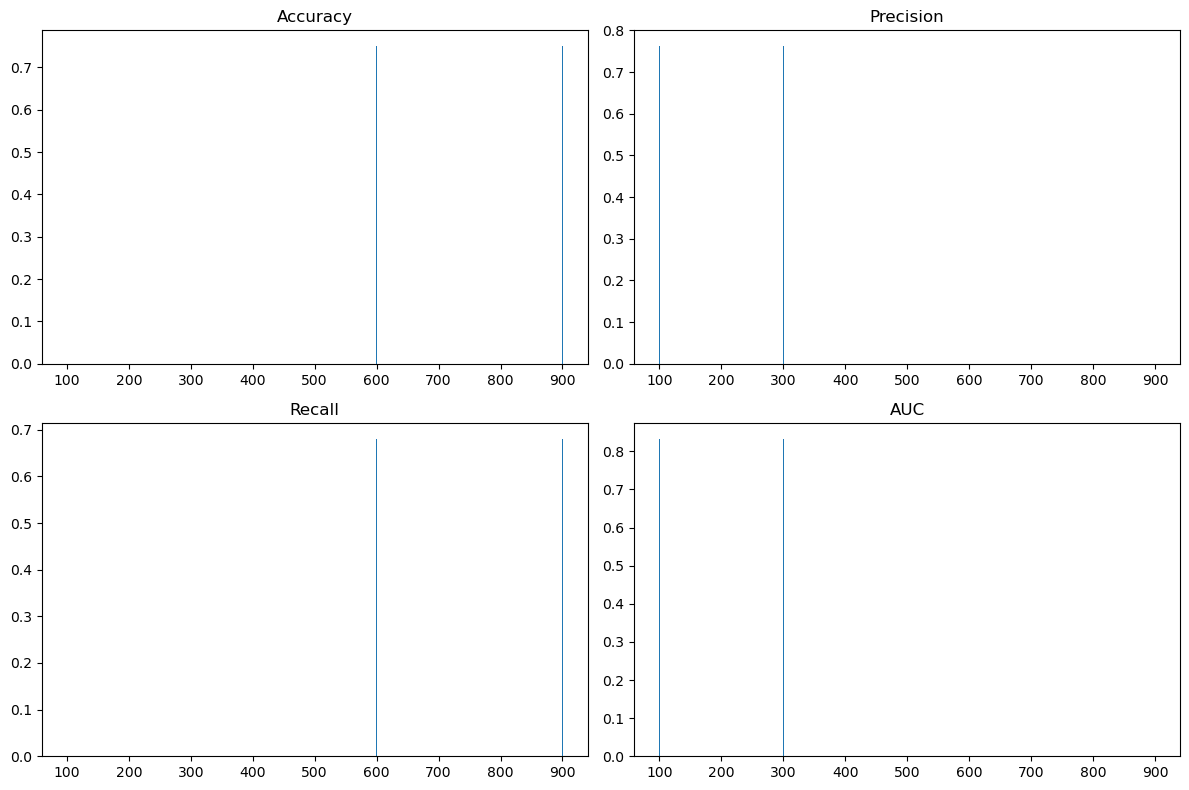

In [6]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Load datasets
train_data = pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\100D_heart_disease_dataset.csv")
test_data  = pd.read_csv(r"C:\Users\Harsh\OneDrive\Desktop\DATASETS\100D_test_dataset.csv")

# Split into features and target
X_train_full = train_data.drop("target", axis=1)
y_train_full = train_data["target"]

X_test = test_data.drop("target", axis=1)
y_test = test_data["target"]

# Training sizes
sizes = [100, 300, 600, 900]

accuracy_list = []
precision_list = []
recall_list = []
auc_list = []

plt.figure(figsize=(10, 7))

# Loop over train sizes
for size in sizes:
    X_small = X_train_full[:size]
    y_small = y_train_full[:size]

    model = KNeighborsClassifier(n_neighbors=9)  # default K=5
    model.fit(X_small, y_small)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    auc_list.append(auc)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{size}D (AUC={auc:.2f})")

# Plot ROC curves
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC for Different Train Sizes (KNN)")
plt.legend()
plt.show()

# Bar chart for metrics
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.bar(sizes, accuracy_list)
plt.title("Accuracy")

plt.subplot(2, 2, 2)
plt.bar(sizes, precision_list)
plt.title("Precision")

plt.subplot(2, 2, 3)
plt.bar(sizes, recall_list)
plt.title("Recall")

plt.subplot(2, 2, 4)
plt.bar(sizes, auc_list)
plt.title("AUC")

plt.tight_layout()
plt.show()


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 2.3.5 which is incompatible.
scipy 1.11.1 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.3.5 which is incompatible.


  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/e3/f8/9246d3c7e185a29d7359d8b12b3d70bf2c3150ecf1427ec1382290e71a56/tensorflow-2.20.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/8f/aa/ba0014cc4659328dc818a28827be78e6d97312ab0cb98105a770924dc11e/absl_py-2.3.1-py3-none-any.whl.metadata
  Obtaining dependency information for astunparse>=1.6.0 from https://files.pythonhosted.org/packages/2b/03/13dde6512ad7b4557eb792fbcf0c653af6076b81e5941d36ec61f7ce6028/astunparse-1.6.3-py2.py3-none-any.whl.metadata
  Obtaining dependency information for flatbuffers>=24.3.25 from https://files.pythonhosted.org/packages/ee/1b/00a78aa2e8fbd63f9af08c9c19e6deb3d5d66b4dda677a0f61654680ee89/flatbuffers-25.9.23-py2.py3-none-any.whl.metadata
  Obtaining dependency information for gast!=0.5.0,!=0.5.1,!=0.5.2,>=0.2.1 from https://files.pythonhosted.org/packages/a3/61/8001b38461d751c

Note: you may need to restart the kernel to use updated packages.
